In [ ]:
import numpy as np
import vbcsr
from vbcsr import VBCSR, MPI, HAS_MPI
from scipy.linalg import eigh_tridiagonal

def ozaki_residues(M_cut:int=1000):
    """
    It computes the poles and residues of the Ozaki formulism.

    Parameters
    ----------
    M_cut (int (optional)): The cutoff, i.e. 2 * M_cut is dimension of the Ozaki matrix.

    Returns
    -------
    poles: The positive half of poles, in ascending order.
    res: The residues of positive half of poles.
    ref:  Karrasch, C., V. Meden, and K. Schönhammer. "Finite-temperature linear conductance from the Matsubara Greens function without analytic continuation to the real axis." Physical Review B 82.12 (2010): 125114.
    """
    if not isinstance(M_cut, int):
        M_cut = int(M_cut)
    # diagonal part of Ozaki matrix

    N_curt = int(2 * M_cut)
    diag = np.zeros(N_curt)
    # off-diagonal part of Ozaki matrix
    off_diag = np.array([.5 / np.sqrt((2. * n - 1) * (2. * n + 1)) for n in range(1, N_curt)])
    # The reciprocal of poles (eigenvalues) are in numerically ascending order, we just need the positive half.
    evals, evecs = eigh_tridiagonal(d=diag, e=off_diag, select='i', select_range=(N_curt // 2, N_curt - 1))
    # return poles in ascending order
    poles = np.flip(1. / evals)
    # compute residues
    res = np.flip(np.abs(evecs[0, :]) ** 2 / (4. * evals ** 2)) # eq.12

    return poles, res

def create_graphene_hamiltonian(nx, ny, t=-2.7):
    """Create a graphene Hamiltonian (honeycomb lattice)."""
    comm = MPI.COMM_WORLD
    rank = comm.Get_rank() if hasattr(comm, 'Get_rank') else 0
    size = comm.Get_size() if hasattr(comm, 'Get_size') else 1
    
    n_atoms = 2 * nx * ny
    atoms_per_rank = (n_atoms + size - 1) // size
    start_atom = rank * atoms_per_rank
    end_atom = min((rank + 1) * atoms_per_rank, n_atoms)
    
    owned_indices = list(range(start_atom, end_atom))
    block_sizes = [1] * len(owned_indices)
    
    def get_idx(ix, iy, sub):
        return (ix % nx) * ny * 2 + (iy % ny) * 2 + sub

    adj = []
    for i in owned_indices:
        ix = i // (ny * 2)
        iy = (i % (ny * 2)) // 2
        sub = i % 2
        neighbors = []
        if sub == 0: # A atom
            neighbors.extend([get_idx(ix, iy, 1), get_idx(ix - 1, iy, 1), get_idx(ix, iy - 1, 1)])
        else: # B atom
            neighbors.extend([get_idx(ix, iy, 0), get_idx(ix + 1, iy, 0), get_idx(ix, iy + 1, 0)])
        neighbors.append(i)
        adj.append(list(set(neighbors)))

    H = VBCSR.create_distributed(owned_indices, block_sizes, adj, dtype=np.complex128, comm=comm)
    for i in owned_indices:
        ix = i // (ny * 2)
        iy = (i % (ny * 2)) // 2
        sub = i % 2
        if sub == 0:
            H.add_block(i, get_idx(ix, iy, 1), np.array([[t]], dtype=np.complex128))
            H.add_block(i, get_idx(ix - 1, iy, 1), np.array([[t]], dtype=np.complex128))
            H.add_block(i, get_idx(ix, iy - 1, 1), np.array([[t]], dtype=np.complex128))
        else:
            H.add_block(i, get_idx(ix, iy, 0), np.array([[t]], dtype=np.complex128))
            H.add_block(i, get_idx(ix + 1, iy, 0), np.array([[t]], dtype=np.complex128))
            H.add_block(i, get_idx(ix, iy + 1, 0), np.array([[t]], dtype=np.complex128))
    H.assemble()
    return H


In [2]:
T = 100
poles, res = ozaki_residues(200)
poles = 1j * poles * 8.617e-5 * T

In [31]:
from scipy.sparse.linalg import LinearOperator, gmres, cg, minres

n = 21
H = create_graphene_hamiltonian(n, n)
vec = np.random.randn(H.shape[0]) + 0j
x = vec.copy()

def callback(rk):
    history.append(rk)
    # print(f"Iteration {len(history):4d}: residual = {rk:10.2e}")

for pole in poles[[0]]:
    history = []
    H.shift(pole)
    # Hinv = Hmask.spmf("inv", method="dense")
    x, info = gmres(H, vec, callback=callback, maxiter=1000, rtol=1e-10)
    print(f"GMRES: info={info}, iters={len(history)}, residual={np.linalg.norm(H @ x - vec)}")
    H.shift(-pole)

GMRES: info=1000, iters=1000, residual=0.028160510335300447


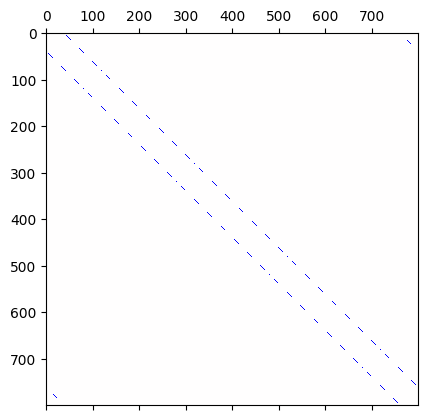

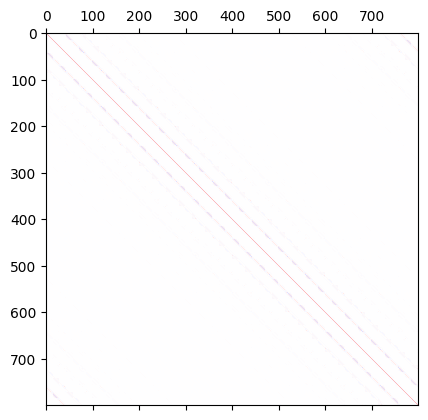

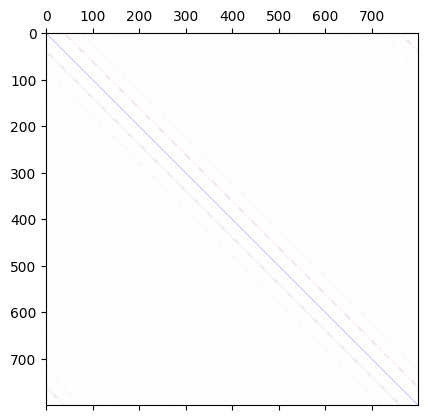

In [56]:
import matplotlib.pyplot as plt
n = 20
H = create_graphene_hamiltonian(n, n)
hd = H.to_dense()
V, U = np.linalg.eigh(hd)
hdisqrt = U @ np.diag(1.0/np.sqrt(V+1e-6+0j)) @ U.conj().T
plt.matshow(hd.real, cmap="bwr", vmax=1.0, vmin=-1.0)
plt.matshow(hdisqrt.real, cmap="bwr", vmax=1.0, vmin=-1.0)
plt.matshow(hdisqrt.imag, cmap="bwr", vmax=1.0, vmin=-1.0)
plt.show()

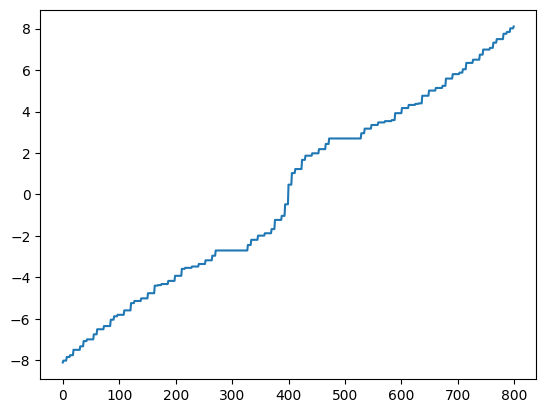

In [57]:
plt.plot(np.linalg.eigvalsh(hd))

In [29]:
hd = Hinv.to_dense()
print(np.abs(hd-hd.conj().T).max())

8.773898274583303e-11


In [42]:
np.abs(Hinv.to_dense().imag).max()

np.float64(0.0)